In [38]:
# Install required packages first

#for file and system operations
import urllib.request
import os

#for data download
import yfinance as yf

#for data manipulattion
import pandas as pd
import datetime as dt
import re

#for time series analysis
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression

#for time series forecasting
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from prophet import Prophet

#for time series forecasting with LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from keras.models import Sequential
    from keras.layers import Dense, LSTM
    from keras.optimizers import Adam
except ImportError as e:
    print(f"Error importing TensorFlow/Keras: {e}")
    print("Please make sure TensorFlow and Keras are properly installed")

from sklearn.preprocessing import MinMaxScaler

#for data visualization
import matplotlib.pyplot as plt
import mplfinance as mpf
import plotly.express as px
import plotly.graph_objects as go

#for suppressing warnings
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

%matplotlib inline

### Load the Data

In [39]:
start = "2024-01-01"
end = dt.datetime.now().strftime("%Y-%m-%d")

data = yf.download("MSFT", start=start, end=end)
data.columns = [col[0] for col in data.columns]

[*********************100%***********************]  1 of 1 completed


### Confirm loaded data

In [40]:
print("1.) The number of observations and variables")
display(data.shape)

print("\n2.) The data types")
display(data.info())

1.) The number of observations and variables


(456, 5)


2.) The data types
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 456 entries, 2024-01-02 to 2025-10-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   456 non-null    float64
 1   High    456 non-null    float64
 2   Low     456 non-null    float64
 3   Open    456 non-null    float64
 4   Volume  456 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 21.4 KB


None

In [41]:
print("\n3.) The summary of numeric columns")
display(data.describe())

print("\n4.) The whole dataset")
display(data)

print("\n 5.) The last 5 rows in the dataset")
display(data.tail())


3.) The summary of numeric columns


,Close,High,Low,Open,Volume
count,456.000000,456.000000,456.000000,456.000000,4.560000e+02
mean,434.436120,437.907167,430.606353,434.380928,2.105342e+07
std,43.118127,43.057249,43.374712,43.378224,7.705614e+06
min,353.329437,363.215009,343.593365,349.662226,7.164500e+06
25%,406.152313,409.270388,402.487580,405.797450,1.631445e+07
50%,420.754349,423.639523,416.700576,420.665161,1.925250e+07
75%,454.344460,457.168452,450.312209,453.857355,2.311690e+07
max,534.760925,554.538376,531.027040,554.318706,6.426370e+07



4.) The whole dataset


,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,366.105560,371.070940,362.058226,369.057139,25258600
2024-01-03,365.839020,368.464851,363.775873,364.269450,23083500
2024-01-04,363.213226,368.306942,362.453129,365.908166,20901500
2024-01-05,363.025635,367.280263,361.791693,364.229963,21004600
2024-01-08,369.876526,370.379984,364.269502,364.555754,23134000
...,...,...,...,...,...
2025-10-20,516.789978,518.700012,513.429993,514.609985,14665600
2025-10-21,517.659973,518.690002,513.039978,517.500000,15586200
2025-10-22,520.539978,525.229980,517.710022,521.150024,18962700



 5.) The last 5 rows in the dataset


,Close,High,Low,Open,Volume
Date,,,,,
2025-10-20,516.789978,518.700012,513.429993,514.609985,14665600
2025-10-21,517.659973,518.690002,513.039978,517.500000,15586200
2025-10-22,520.539978,525.229980,517.710022,521.150024,18962700
2025-10-23,520.559998,523.950012,518.609985,522.460022,14023500
2025-10-24,523.609985,525.349976,520.710022,522.789978,15517500


### Save the Original Data

In [42]:
output_path = './data/microsoft_stockprice_original.csv'

#Ensure data dir exists
if not os.path.exists('./data'):
    os.makedirs('./data')
# Save the CSV file regardless of environment (Google Colab or local)
data.to_csv(output_path, index=True)
print(f"\n✅ Results saved to {output_path}")

# Provide a download link if running in Google Colab
try:
    from google.colab import files
    files.download(output_path)
except ImportError:
    print("❌ Not running in Google Colab, skipped dataset download link.")


✅ Results saved to ./data/microsoft_stockprice_original.csv
❌ Not running in Google Colab, skipped dataset download link.


### Data Cleaning and Preparation

In [43]:
# 1) Ensure datetime index and sorted

# This line converts the `Date` column in the `data` DataFrame to datetime
# objects. The `errors="coerce"` argument means that any value that cannot
# be parsed as a date will be replaced with `NaT` (Not a Time), which is
# pandas' way of marking missing or invalid dates. This helps prevent errors
# from invalid date formats and ensures the column is consistently typed.
if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    data = data.set_index("Date")

data = data.sort_index()

# 2) Normalize column names (trim, unify, and fix common naming)
data.columns = [c.strip() for c in data.columns]
rename_map = {
    "Close/Last": "Close",
    "Adj Close": "Close",
    "Adj. Close": "Close",
    "Closing Price": "Close",
    "Open Price": "Open",
    "Opening Price": "Open",
    "High Price": "High",
    "Low Price": "Low",
    "Trade Volume": "Volume",
    "Volume (Shares)": "Volume",
    "Total Volume": "Volume",
    "High/Low": "High",
    "Low/High": "Low"
}
data = data.rename(columns=rename_map)

# 3) Define a helper to strip non-numeric characters (keep digits, dot, minus)
def to_numeric_str(s: str) -> str:
    # Handle None/NaN safely
    s = "" if s is None else str(s)
    # Strip any characters except digits, decimal point, minus
    return re.sub(r"[^0-9.\-]", "", s)

# 4) Coerce OHLC to float
ohlc_cols = [c for c in ["Open", "High", "Low", "Close"] if c in data.columns]
for c in ohlc_cols:
    data[c] = pd.to_numeric(data[c].astype(str).map(to_numeric_str), errors="coerce")

# 5) Coerce Volume to numeric (basic version: strip non-numeric)
if "Volume" in data.columns:
    data["Volume"] = pd.to_numeric(data["Volume"].astype(str).map(to_numeric_str), errors="coerce")

# Optional: if your Volume has K/M/B suffixes (e.g., 12K, 3.5M, 1.2B) and you want correct scaling:
def parse_volume(v):
    v = str(v).strip()
    if not v or v.lower() == "nan":
        return float("nan")
    mult = 1
    if v[-1] in "KkMmBb":
        suffix = v[-1].upper()
        v = to_numeric_str(v[:-1])
        mult = {"K": 1_000, "M": 1_000_000, "B": 1_000_000_000}[suffix]
    else:
        v = to_numeric_str(v)
    return float(v) * mult if v else float("nan")
if "Volume" in data.columns:
    data["Volume"] = data["Volume"].map(parse_volume)

# 6) Drop rows where any of OHLC are missing (mplfinance needs valid OHLC rows)
if ohlc_cols:
    data = data.dropna(subset=ohlc_cols)

### Confirm Cleaned Data


In [44]:
print('1.) The total number of observations and variables')
display(data.shape)

print('\n 2.) The data types')
display(data.info())

print('\n 3.) The summary of numeric columns')
display(data.describe())

print('\n 4.) The summary of the entire dataset')
display(data)

1.) The total number of observations and variables


(456, 5)


 2.) The data types
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 456 entries, 2024-01-02 to 2025-10-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   456 non-null    float64
 1   High    456 non-null    float64
 2   Low     456 non-null    float64
 3   Open    456 non-null    float64
 4   Volume  456 non-null    float64
dtypes: float64(5)
memory usage: 21.4 KB


None


 3.) The summary of numeric columns


,Close,High,Low,Open,Volume
count,456.000000,456.000000,456.000000,456.000000,4.560000e+02
mean,434.436120,437.907167,430.606353,434.380928,2.105342e+07
std,43.118127,43.057249,43.374712,43.378224,7.705614e+06
min,353.329437,363.215009,343.593365,349.662226,7.164500e+06
25%,406.152313,409.270388,402.487580,405.797450,1.631445e+07
50%,420.754349,423.639523,416.700576,420.665161,1.925250e+07
75%,454.344460,457.168452,450.312209,453.857355,2.311690e+07
max,534.760925,554.538376,531.027040,554.318706,6.426370e+07



 4.) The summary of the entire dataset


,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,366.105560,371.070940,362.058226,369.057139,25258600.0
2024-01-03,365.839020,368.464851,363.775873,364.269450,23083500.0
2024-01-04,363.213226,368.306942,362.453129,365.908166,20901500.0
2024-01-05,363.025635,367.280263,361.791693,364.229963,21004600.0
2024-01-08,369.876526,370.379984,364.269502,364.555754,23134000.0
...,...,...,...,...,...
2025-10-20,516.789978,518.700012,513.429993,514.609985,14665600.0
2025-10-21,517.659973,518.690002,513.039978,517.500000,15586200.0
2025-10-22,520.539978,525.229980,517.710022,521.150024,18962700.0


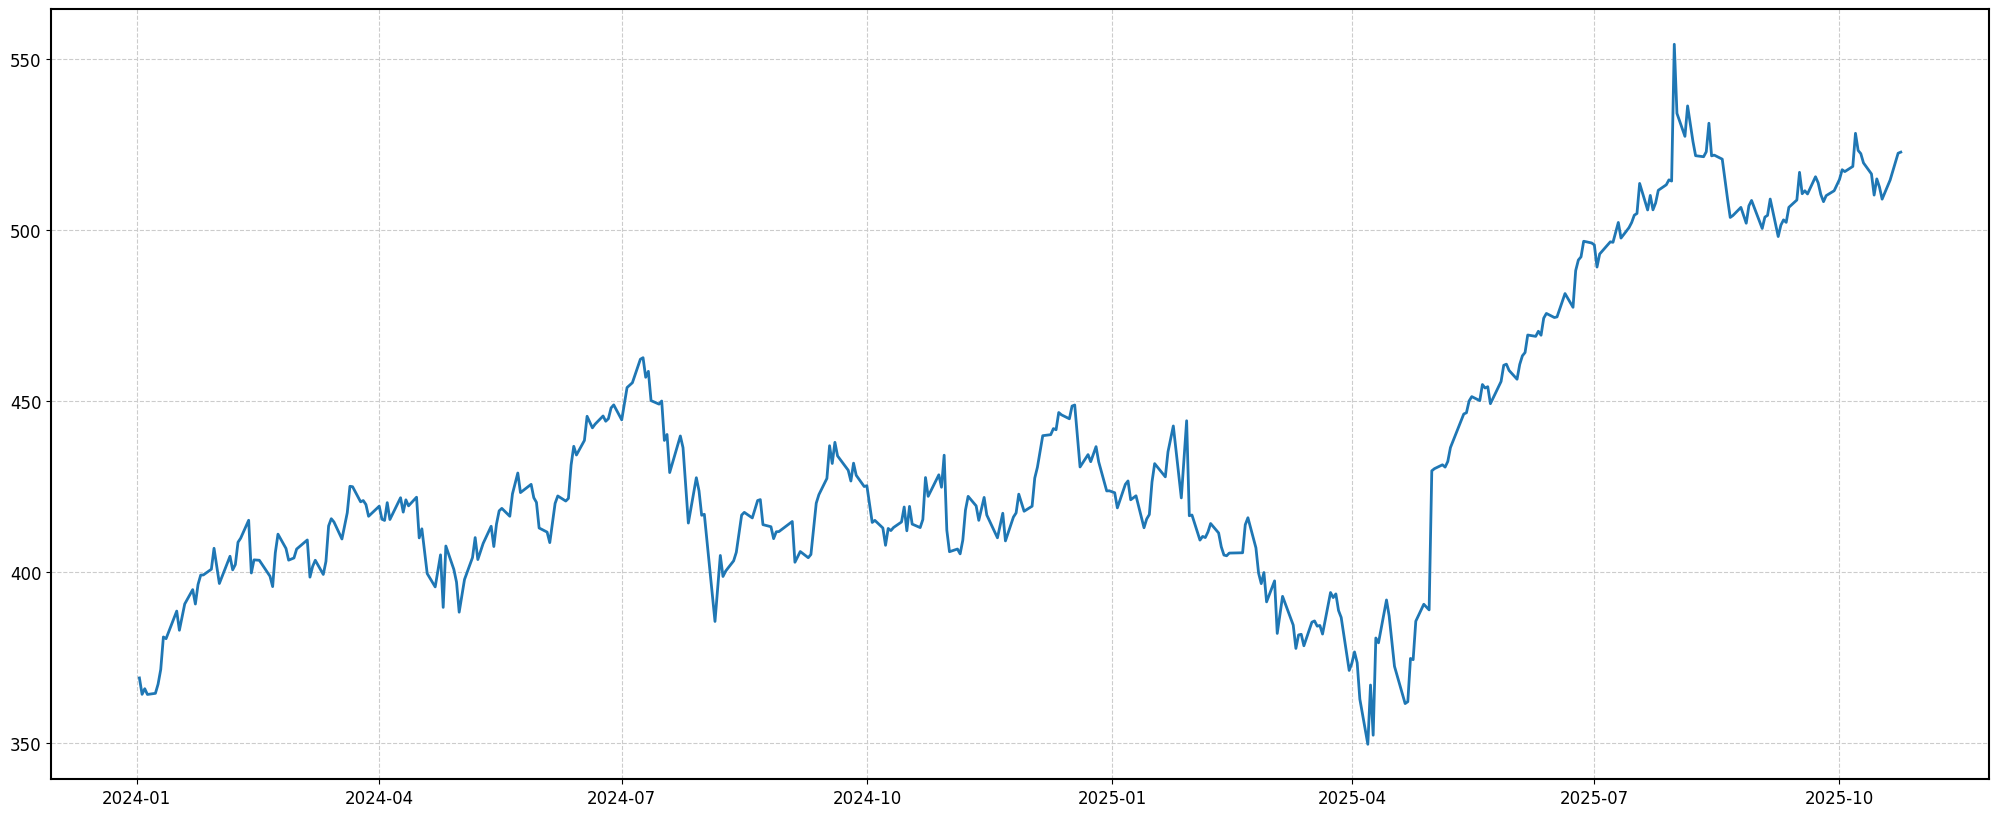

In [45]:
plt.figure(figsize=(25, 10))
plt.plot(data["Open"])
plt.show()


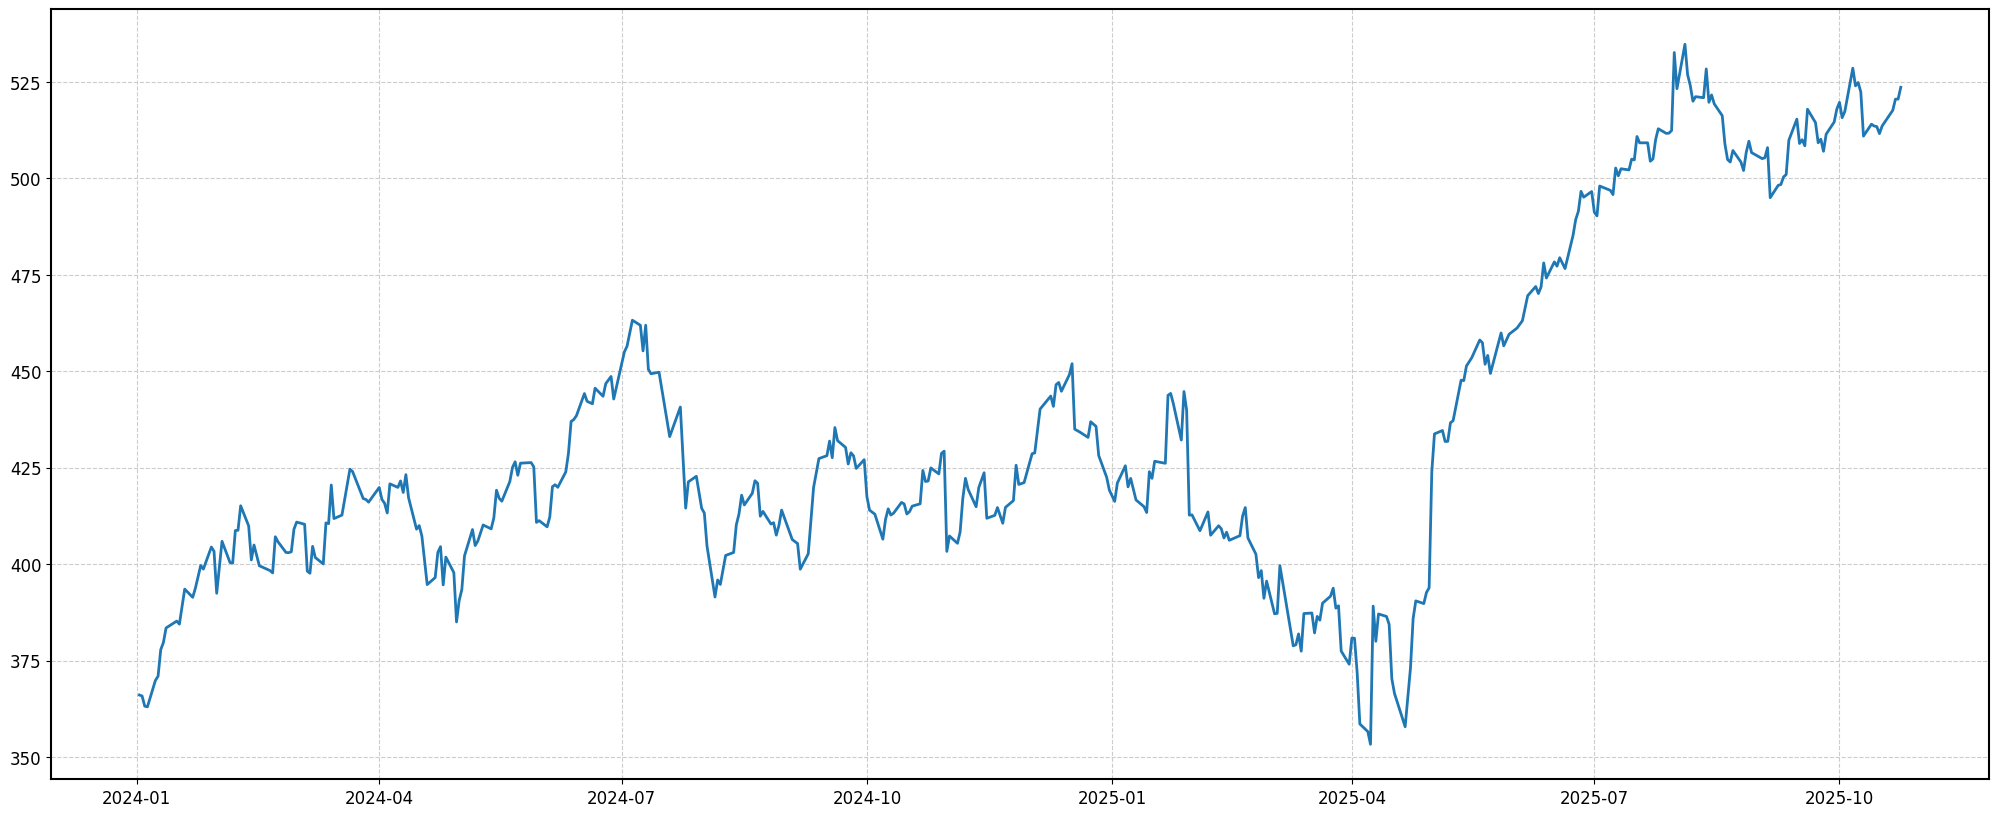

In [46]:
plt.figure(figsize=(25, 10))
plt.plot(data["Close"])
plt.show()

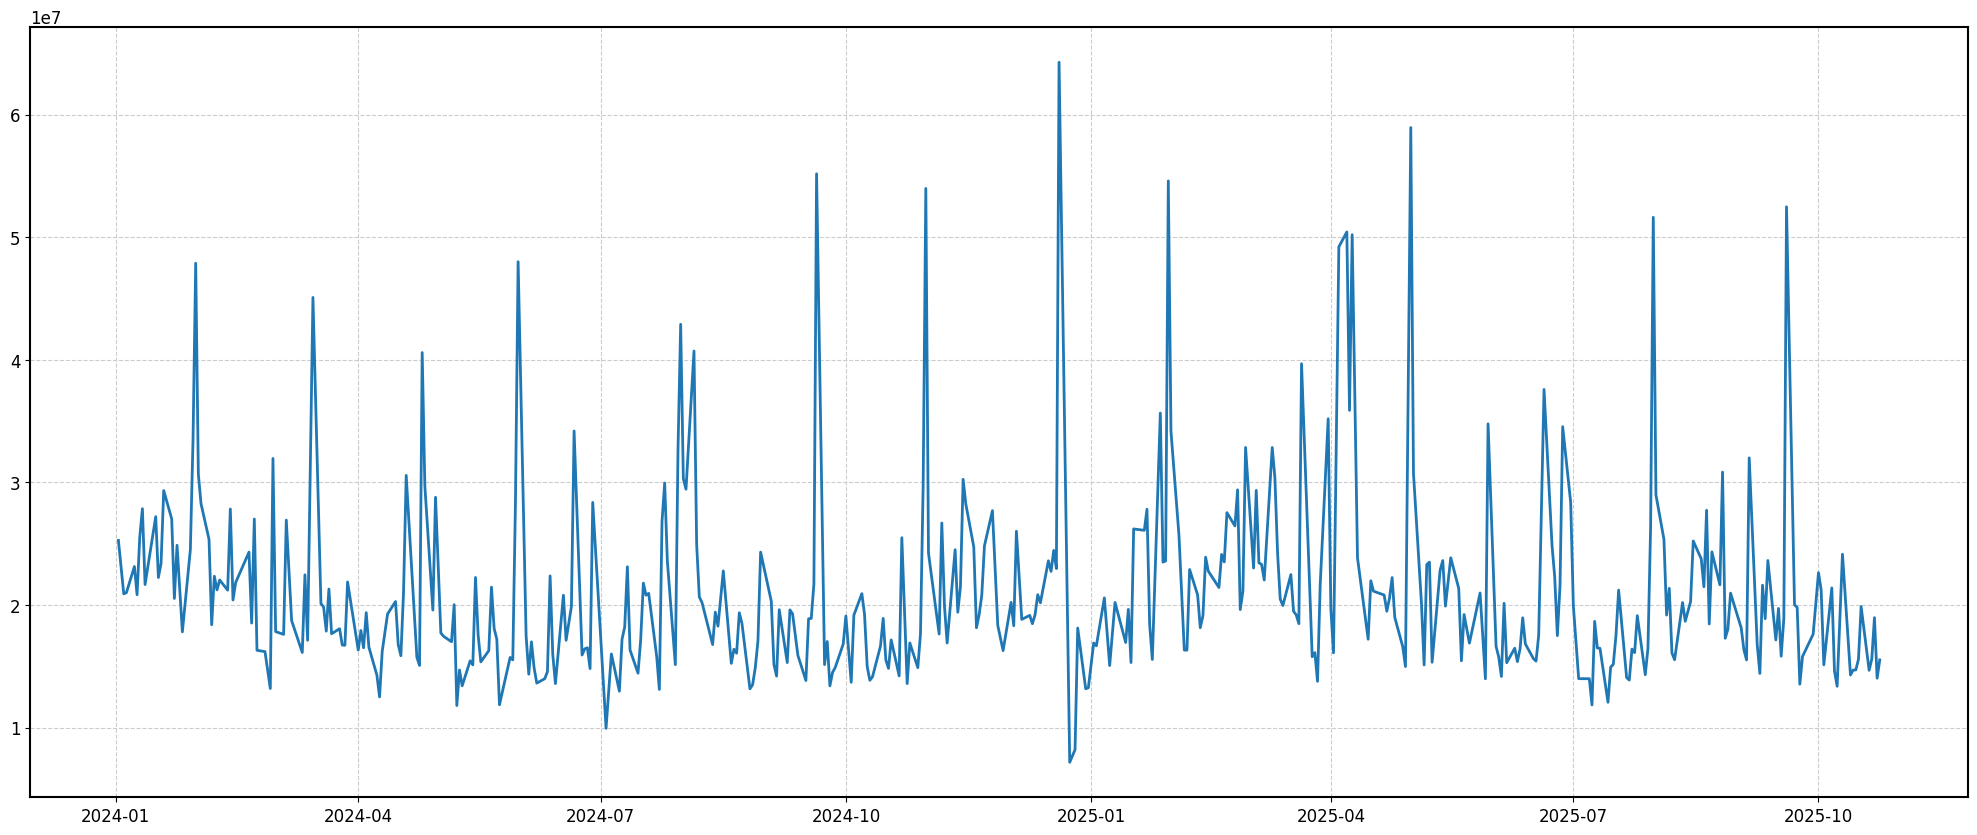

In [47]:
plt.figure(figsize=(25, 10))
plt.plot(data["Volume"])
plt.show()

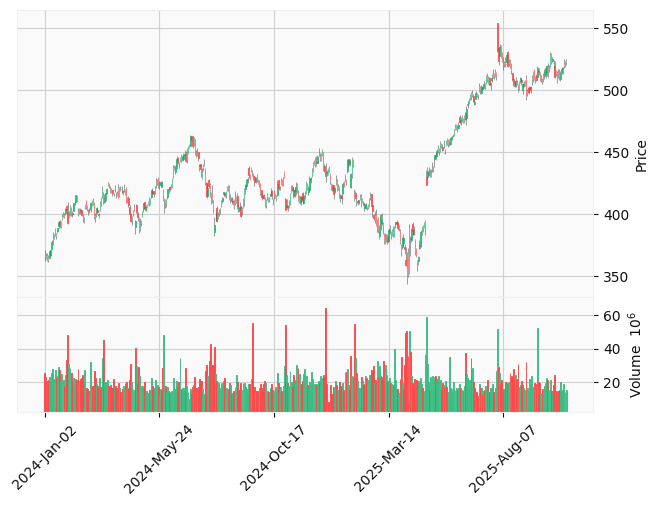

In [48]:
mpf.plot(data, type = "candle", style="yahoo", volume = ("Volume" in data.columns))

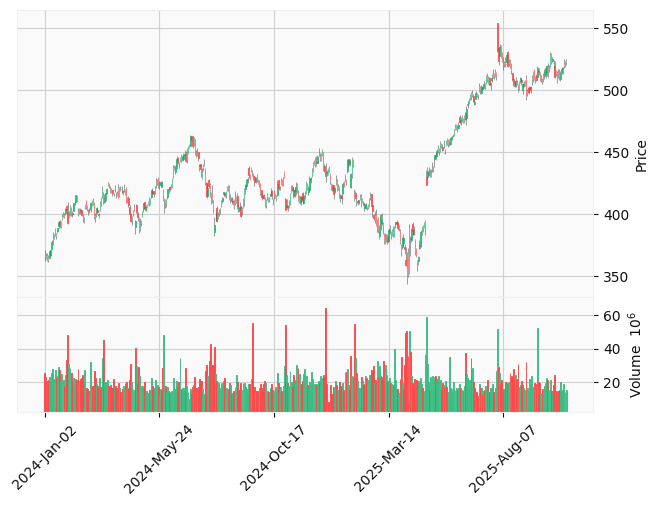

In [49]:
mpf.plot(data, type="candle", style="yahoo", volume=True)

### Save the cleaned Data

In [50]:
# Save the results as a CSV file for further analysis and reporting
output_path = './data/microsoft_stockprice_cleaned.csv'
# Ensure the data directory exists
if not os.path.exists('./data'):
    os.makedirs('./data')
# Save the CSV file regardless of environment (Google Colab or local)
data.to_csv(output_path, index=True)
print(f"\n✅ Results saved to {output_path}")

# Provide a download link if running in Google Colab
try:
    from google.colab import files
    files.download(output_path)
except ImportError:
    print("❌ Not running in Google Colab, skipped dataset download link.")


✅ Results saved to ./data/microsoft_stockprice_cleaned.csv
❌ Not running in Google Colab, skipped dataset download link.


### Drill down to Specific Month Range and plot chart

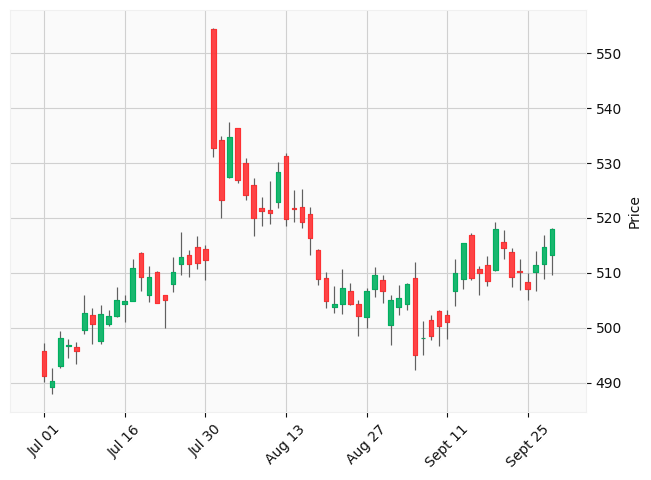

In [51]:
# Ensure datetime index
data.index = pd.to_datetime(data.index)

# Define a range of months
start_month = "2025-07"
end_month   = "2025-09"

try:
    # Use .loc to slice safely using a date range
    month_df = data.loc[start_month:end_month]
except KeyError:
    raise ValueError(
        f"No data available from {start_month} to {end_month}. "
        f"Available range: {data.index.min().date()} to {data.index.max().date()}"
    )

# Check if DataFrame is empty
if month_df.empty:
    raise ValueError(
        f"No data available from {start_month} to {end_month}. "
        f"Available range: {data.index.min().date()} to {data.index.max().date()}"
    )
else:
    # Plot candlestick with volume disabled
    mpf.plot(month_df, type="candle", style="yahoo", volume=False)

- Add your own customer colours

In [52]:
colors = mpf.make_marketcolors(up="green", down="red", edge="inherit", wick="inherit", volume="in")
custom_mpf_style = mpf.make_mpf_style(base_mpf_style="classic", marketcolors=colors)

### Add Short, Medium and Long-Term Moving Averages

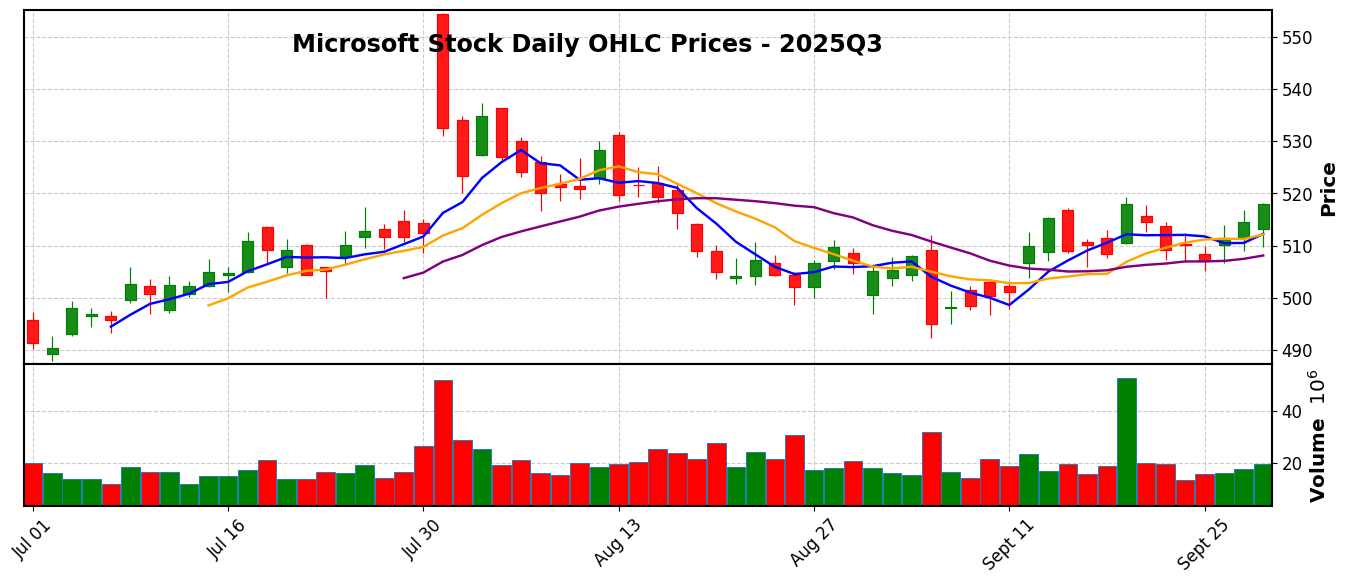

In [53]:
mpf.plot(
    month_df,
    type='candle',
    mav=(5, 10, 20),
    mavcolors=['blue', 'orange', 'purple'],
    volume=True,
    tight_layout=True,
    figratio=(25, 10),
    title='Microsoft Stock Daily OHLC Prices - 2025Q3',
    style=custom_mpf_style
)

### Load cleaned data

In [54]:
dataset_path = './data/microsoft_stockprice_cleaned.csv'

if not os.path.exists(dataset_path):
    print("❌ Please create the dataset first using the previous Jupyter Notebook.")
else:
    print("✅ Dataset exists locally")

data = pd.read_csv(dataset_path, encoding='utf-8', nrows=200000)

✅ Dataset exists locally


### Preprocess cleaned data


In [55]:
# 1) Ensure datetime index and sorted

# This line converts the `Date` column in the `data` DataFrame to datetime
# objects. The `errors="coerce"` argument means that any value that cannot
# be parsed as a date will be replaced with `NaT` (Not a Time), which is
# pandas' way of marking missing or invalid dates. This helps prevent errors
# from invalid date formats and ensures the column is consistently typed.
if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    data = data.set_index("Date")

data = data.sort_index()

# 2) Normalize column names (trim, unify, and fix common naming)
data.columns = [c.strip() for c in data.columns]
rename_map = {
    "Close/Last": "Close",
    "Adj Close": "Close",
    "Adj. Close": "Close",
    "Closing Price": "Close",
    "Open Price": "Open",
    "Opening Price": "Open",
    "High Price": "High",
    "Low Price": "Low",
    "Trade Volume": "Volume",
    "Volume (Shares)": "Volume",
    "Total Volume": "Volume",
    "High/Low": "High",
    "Low/High": "Low"
}
data = data.rename(columns=rename_map)

# 3) Define a helper to strip non-numeric characters (keep digits, dot, minus)
def to_numeric_str(s: str) -> str:
    # Handle None/NaN safely
    s = "" if s is None else str(s)
    # Strip any characters except digits, decimal point, minus
    return re.sub(r"[^0-9.\-]", "", s)

# 4) Coerce OHLC to float
ohlc_cols = [c for c in ["Open", "High", "Low", "Close"] if c in data.columns]
for c in ohlc_cols:
    data[c] = pd.to_numeric(data[c].astype(str).map(to_numeric_str), errors="coerce")

# 5) Coerce Volume to numeric (basic version: strip non-numeric)
if "Volume" in data.columns:
    data["Volume"] = pd.to_numeric(data["Volume"].astype(str).map(to_numeric_str), errors="coerce")

# Optional: if your Volume has K/M/B suffixes (e.g., 12K, 3.5M, 1.2B) and you want correct scaling:
def parse_volume(v):
    v = str(v).strip()
    if not v or v.lower() == "nan":
        return float("nan")
    mult = 1
    if v[-1] in "KkMmBb":
        suffix = v[-1].upper()
        v = to_numeric_str(v[:-1])
        mult = {"K": 1_000, "M": 1_000_000, "B": 1_000_000_000}[suffix]
    else:
        v = to_numeric_str(v)
    return float(v) * mult if v else float("nan")
if "Volume" in data.columns:
    data["Volume"] = data["Volume"].map(parse_volume)

# 6) Drop rows where any of OHLC are missing (mplfinance needs valid OHLC rows)
if ohlc_cols:
    data = data.dropna(subset=ohlc_cols)

### Confirm Cleaned Data

In [56]:
print('1.) The total number of observations and variables')
display(data.shape)

print('\n 2.) The data types')
display(data.info())

print('\n 3.) The summary of numeric columns')
display(data.describe())

print('\n 4.) The summary of the entire dataset')
display(data)



1.) The total number of observations and variables


(456, 5)


 2.) The data types
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 456 entries, 2024-01-02 to 2025-10-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   456 non-null    float64
 1   High    456 non-null    float64
 2   Low     456 non-null    float64
 3   Open    456 non-null    float64
 4   Volume  456 non-null    float64
dtypes: float64(5)
memory usage: 21.4 KB


None


 3.) The summary of numeric columns


,Close,High,Low,Open,Volume
count,456.000000,456.000000,456.000000,456.000000,4.560000e+02
mean,434.436120,437.907167,430.606353,434.380928,2.105342e+07
std,43.118127,43.057249,43.374712,43.378224,7.705614e+06
min,353.329437,363.215009,343.593365,349.662226,7.164500e+06
25%,406.152313,409.270388,402.487580,405.797450,1.631445e+07
50%,420.754349,423.639523,416.700576,420.665161,1.925250e+07
75%,454.344460,457.168452,450.312209,453.857355,2.311690e+07
max,534.760925,554.538376,531.027040,554.318706,6.426370e+07



 4.) The summary of the entire dataset


,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,366.105560,371.070940,362.058226,369.057139,25258600.0
2024-01-03,365.839020,368.464851,363.775873,364.269450,23083500.0
2024-01-04,363.213226,368.306942,362.453129,365.908166,20901500.0
2024-01-05,363.025635,367.280263,361.791693,364.229963,21004600.0
2024-01-08,369.876526,370.379984,364.269502,364.555754,23134000.0
...,...,...,...,...,...
2025-10-20,516.789978,518.700012,513.429993,514.609985,14665600.0
2025-10-21,517.659973,518.690002,513.039978,517.500000,15586200.0
2025-10-22,520.539978,525.229980,517.710022,521.150024,18962700.0


### Plot the Data


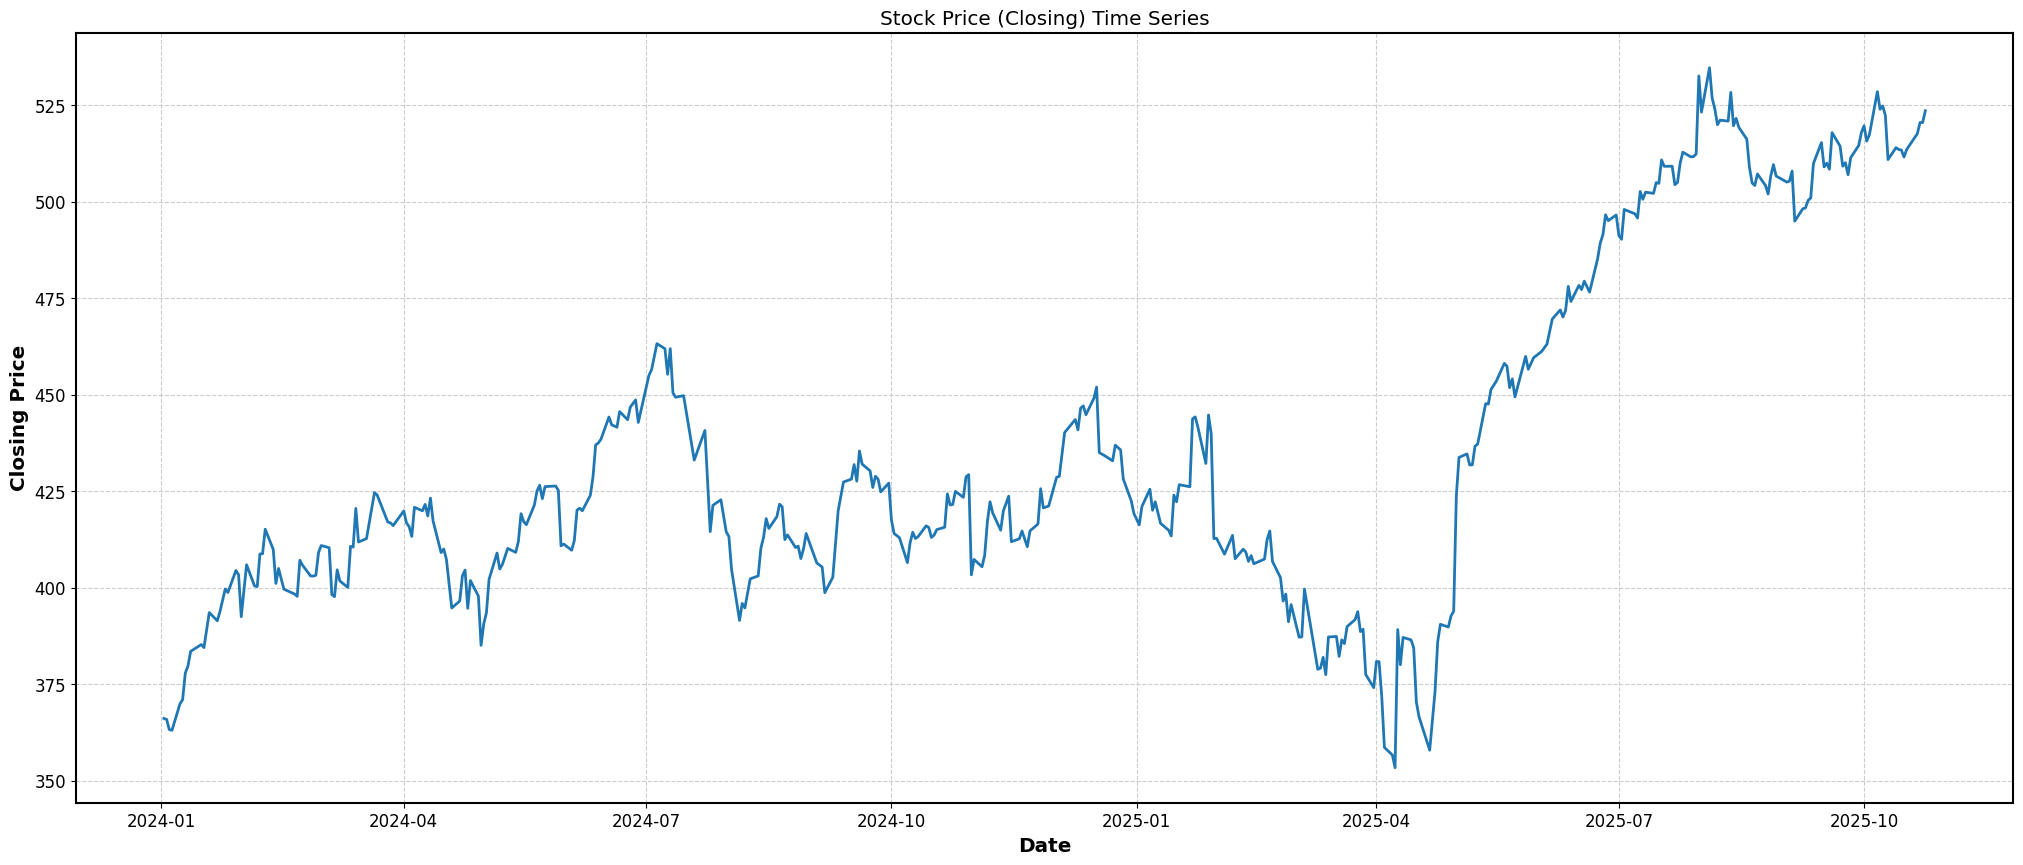

In [57]:
plt.figure(figsize=(25, 10))
plt.plot(data["Close"])
plt.title(f"Stock Price (Closing) Time Series")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

### Decompose The  Time Series into its Components

Detected frequency in the time series data is: None


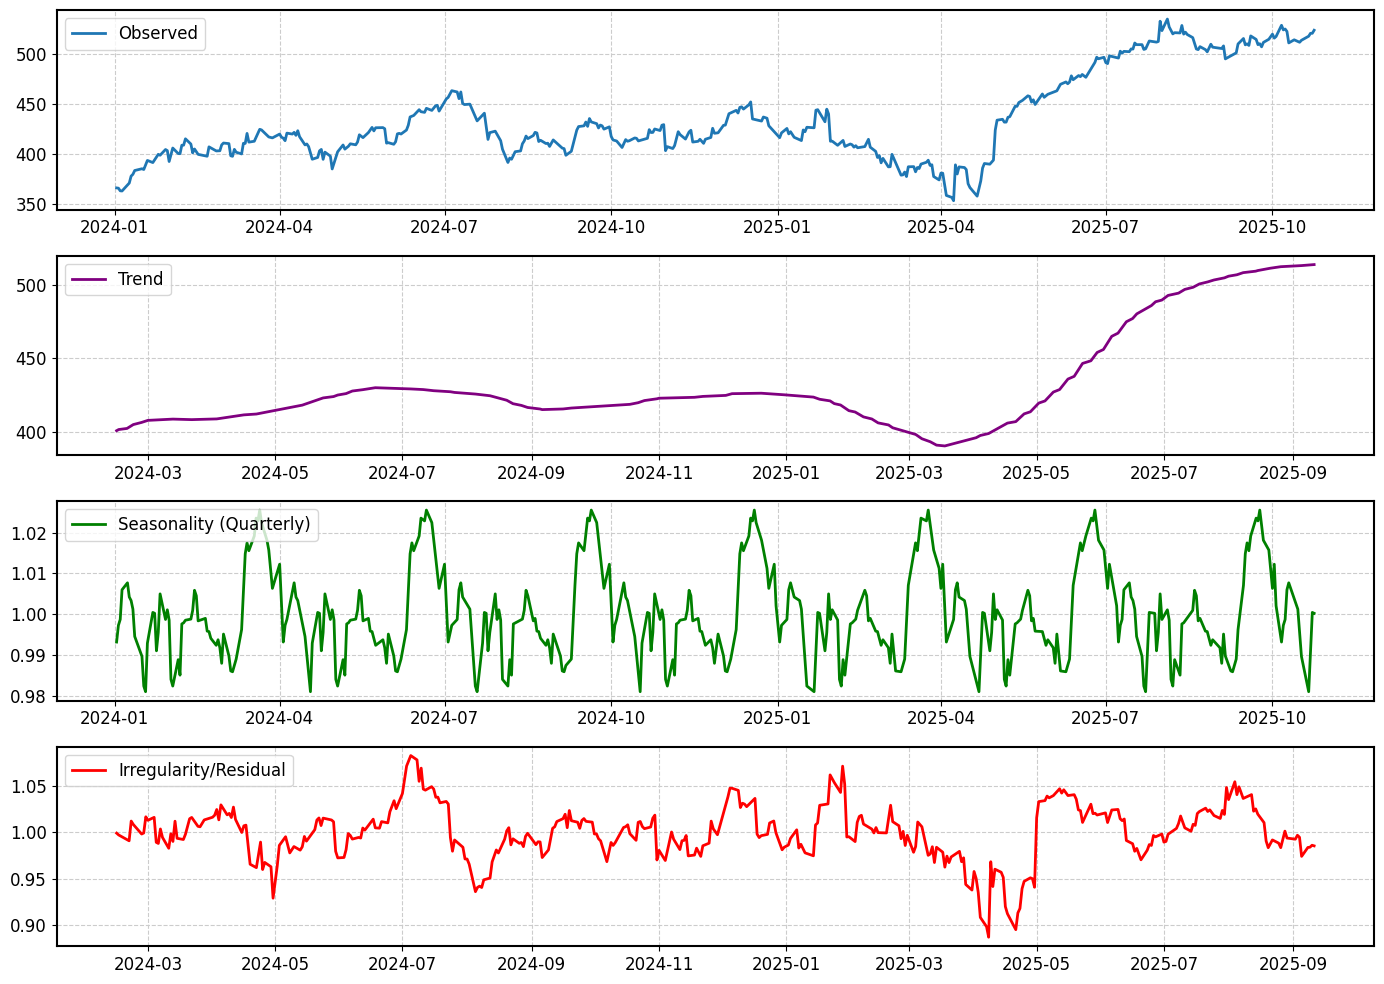

In [58]:
# If data is already a Series, it uses it directly.
# If data is a DataFrame, it selects the Close column and converts it to float64.
ts = data if isinstance(data, pd.Series) else data["Close"].astype('float64')

# Ensure DateTimeIndex and set/keep frequency if possible
if not isinstance(ts.index, pd.DatetimeIndex):
    raise ValueError("Time series index must be a DateTimeIndex for seasonal decomposition.")
# Try to infer frequency if not present
if ts.index.freq is None:
    inferred = pd.infer_freq(ts.index)
    if inferred is not None:
        ts = ts.asfreq(inferred)

# Decide model safely: multiplicative requires strictly positive values
model_to_use = 'multiplicative' if (ts > 0).all() else 'additive'

# Choose a sensible seasonal period based on frequency and desired cycle
# Set which seasonal cycle you want to capture: 'weekly' (trading week) or 'annual' (trading year)
seasonality_target = 'weekly'  # or 'annual'

period = 63  # fallback default
if ts.index.freq is not None:
    freqstr = ts.index.freqstr.upper()
    if 'B' in freqstr:  # Business-day frequency (weekdays only)
        period = 5 if seasonality_target == 'weekly' else 252
    elif 'M' in freqstr:  # Monthly
        period = 12
    elif 'W' in freqstr:  # Weekly
        period = 52
    elif 'Q' in freqstr:  # Quarterly
        period = 4
    elif 'D' in freqstr:  # Calendar daily (weekends included)
        period = 7 if seasonality_target == 'weekly' else 365

print("Detected frequency in the time series data is:", ts.index.freq)

# Decompose the time series
decomposition = seasonal_decompose(ts, model=model_to_use, period=period)

# Plot the components
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='purple')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality (Quarterly)', color='green')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(decomposition.resid, label='Irregularity/Residual', color='red')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Statistical Tests of Stationarity
One of the most commonly used tests is the **Augmented Dickey-Fuller (ADF) test**.

The ADF test is a statistical test for the following hypothesis:

* **Null Hypothesis (H0):** The time series is non-stationary.
* **Alternative Hypothesis (H1):** The time series is stationary.

We interpret the result of the ADF test using the p-value. If the p-value is less than a significance level (e.g., p<.05), we reject the null hypothesis and conclude that the time series is stationary.

In [59]:
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(f'Augmented Dickey-Fuller (ADF) Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    # for key, value in result[4].items():
    #     print('Critial Values:')
    #     print(f'   {key}, {value}')

adf_test(ts)

Augmented Dickey-Fuller (ADF) Statistic: -1.1487720300532576
p-value: 0.6952357505939019


If the p-value is greater than 0.05, we fail to reject the null hypothesis and conclude that the time series is non-stationary. In this case, we need to make the series stationary. A common way to do this is by **differencing** the series.

### Stationarizing Techniques
(Data Transformation)
- Differencing: Taking first differences (Y(t) - Y(t-1))

In [60]:
time_series_differenced = ts.diff().dropna()

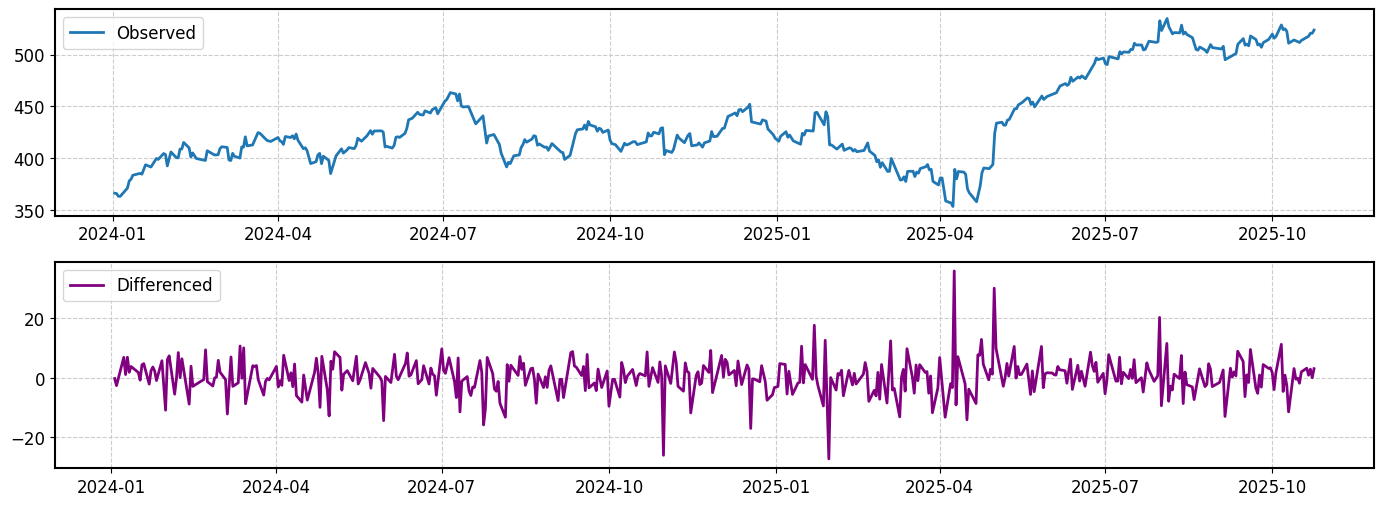

Augmented Dickey-Fuller (ADF) Statistic: -22.322357685215618
p-value: 0.0


In [61]:
# Plot the components
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(time_series_differenced, label='Differenced', color = 'purple')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Perform ADF test on the differenced series
adf_test(time_series_differenced)

### Detrending: Removing trend components

In [62]:
# Prepare the time index as a feature for regression
time_index = np.arange(len(ts)).reshape(-1, 1)

# Fit linear regression (trend)
lr = LinearRegression()
lr.fit(time_index, ts.values)
trend = lr.predict(time_index)

# Detrend the series
time_series_detrended = ts.values - trend

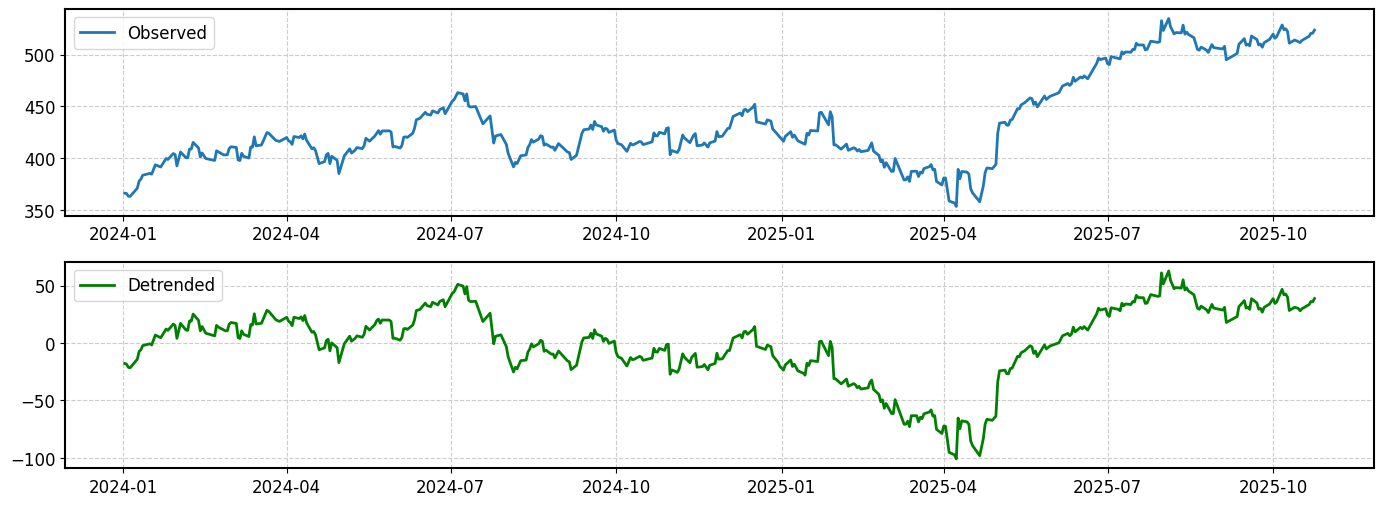

Augmented Dickey-Fuller (ADF) Statistic: -1.8276351022700918
p-value: 0.36683048927101936


In [63]:
# Plot the components
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(ts.index, time_series_detrended, label='Detrended', color = 'green')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Perform ADF test on the detrended series
adf_test(time_series_detrended)

### Log Transformation: For changing variance

In [64]:
time_series_log_transformed = np.log(ts+ 1e-8)

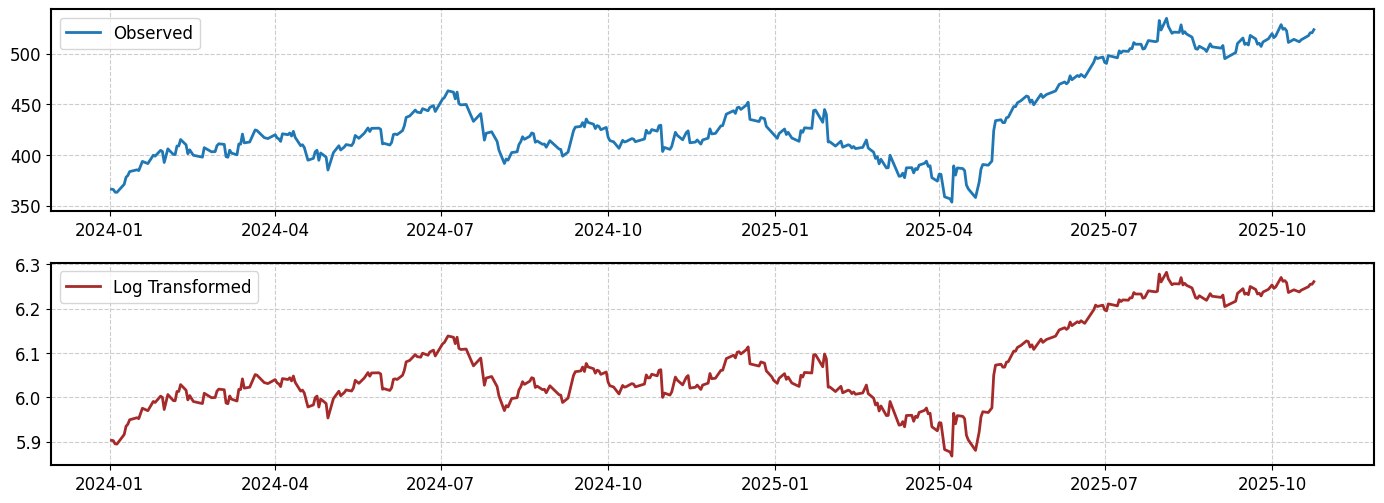

Augmented Dickey-Fuller (ADF) Statistic: -1.3995334300663254
p-value: 0.5824997775627726


In [65]:
# Plot the components
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(ts.index, time_series_log_transformed, label='Log Transformed', color = 'brown')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Perform ADF test on the detrended series
adf_test(time_series_log_transformed)

### Seasonal Differencing: For seasonal patterns

In [66]:
time_series_seasonal_differenced = ts.diff(63).dropna()

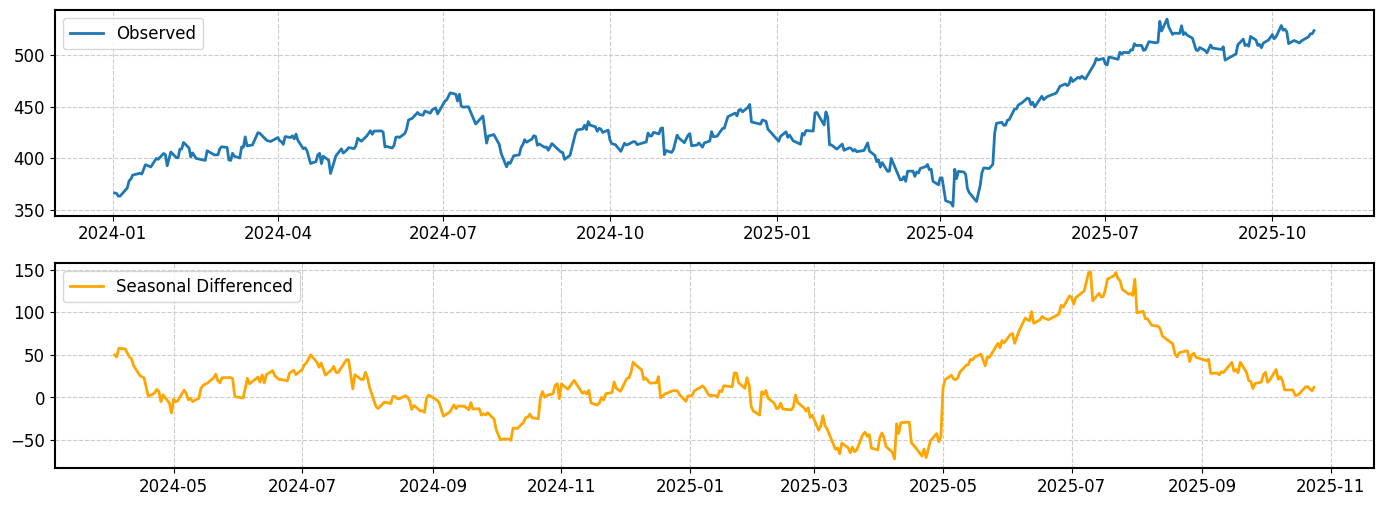

Augmented Dickey-Fuller (ADF) Statistic: -2.0373016233528847
p-value: 0.27046082629456086


In [67]:
# Plot the components
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(time_series_seasonal_differenced, label='Seasonal Differenced', color = 'orange')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Perform ADF test on the detrended series
adf_test(time_series_seasonal_differenced)

### Forecast

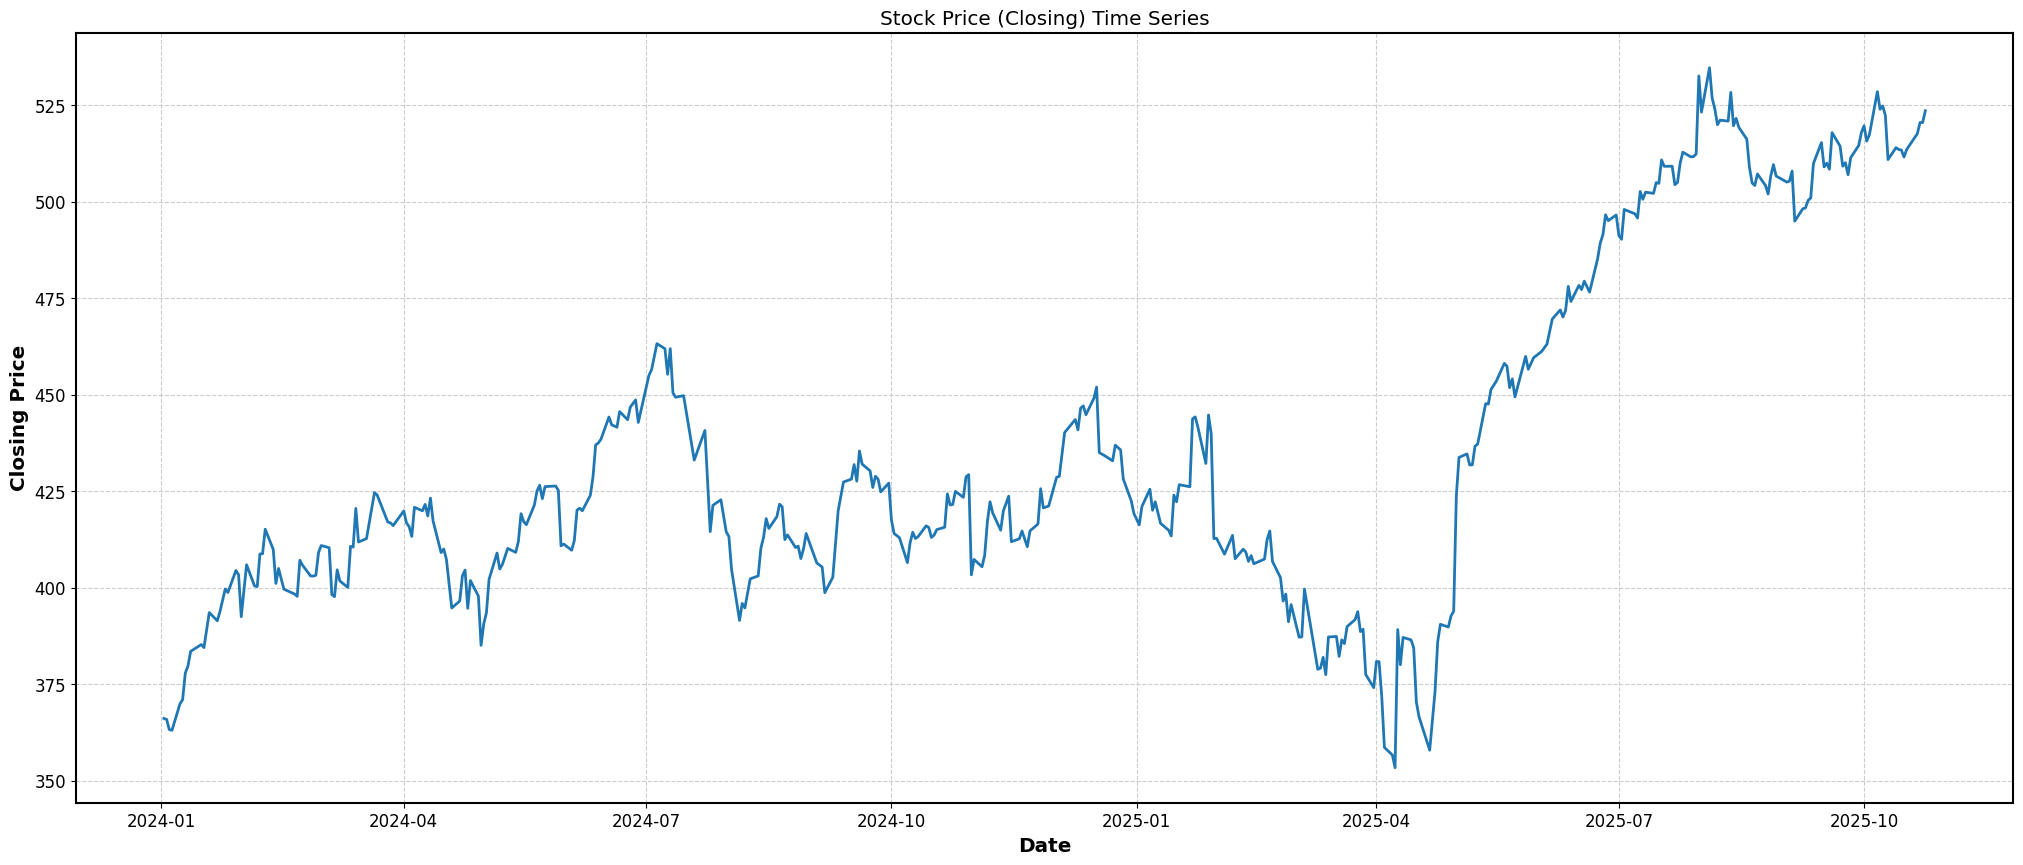

In [68]:
plt.figure(figsize=(25, 10))
plt.plot(data["Close"])
plt.title(f"Stock Price (Closing) Time Series")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [69]:
# If data is already a Series, it uses it directly.
# If data is a DataFrame, it selects the Close column and converts it to float64
ts = data if isinstance(data, pd.Series) else data["Close"].astype('float64')

### Arima


### Prophet

### LSTM with Hyperparameter Tuning
